In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")
df2 = pd.read_csv("LABELED_DATA.csv")
df.head()

,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score,label
0,comment,i2xzv3o,2qh68,canada,False,1648787181,https://old.reddit.com/r/canada/comments/tscyq...,>I know its no use arguing with you because yo...,0.7460,0,"""Climate denial critique"""
1,comment,igzonpx,340dk,askanaustralian,False,1658365540,https://old.reddit.com/r/AskAnAustralian/comme...,"i'm a believer in climate change, don't get me...",0.3854,2,"""Climate opinion"""
2,comment,esa0yio,2r7hk,tumblr,False,1561749008,https://old.reddit.com/r/tumblr/comments/c6hcl...,"Nice try, tumblr SJWs. That animal is a myth, ...",0.4215,3,"""Climate denial"""
3,comment,em6p8mh,2qhw9,collapse,False,1556670814,https://old.reddit.com/r/collapse/comments/bja...,I never disregarded the scientific consensus o...,0.1739,6,"""Climate information"""
4,comment,chveb1w,2s7tt,adviceanimals,False,1401504754,https://old.reddit.com/r/AdviceAnimals/comment...,"So we'll melt the ice caps, cause mass extinct...",0.0000,1,"""climate action critique"""


In [ ]:
df2.tail()

,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score,label
14899,comment,ficx4ao,2qh1i,askreddit,False,1582358770,https://old.reddit.com/r/AskReddit/comments/f7...,If you're talking about those protesters that ...,-0.7972,2,Climate information
14900,comment,gdhelo3,hitz3,stupidpol,False,1606251264,https://old.reddit.com/r/stupidpol/comments/k0...,"First, he's not the labor secretary, there has...",-0.2487,5,Climate action critique
14901,comment,h0sf738,2cneq,politics,False,1622983309,https://old.reddit.com/r/politics/comments/ntc...,They did this with Climate Change too and acte...,0.5859,16,Climate information
14902,comment,hhi4y9u,ovfhp,cringetopia,False,1634831520,https://old.reddit.com/r/Cringetopia/comments/...,Reminder of what chemicals are doing to animal...,-0.9186,2,Climate information
14903,comment,h2krvgf,2qh13,worldnews,False,1624307301,https://old.reddit.com/r/worldnews/comments/o4...,"Um, for elephants, yes it is. Poaching has a f...",0.7717,12,Climate information


In [ ]:
df = pd.concat([df,df2], axis=0)

In [ ]:
df.reset_index(inplace=True)
df.tail()

,index,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score,label
16746,14899,comment,ficx4ao,2qh1i,askreddit,False,1582358770,https://old.reddit.com/r/AskReddit/comments/f7...,If you're talking about those protesters that ...,-0.7972,2,Climate information
16747,14900,comment,gdhelo3,hitz3,stupidpol,False,1606251264,https://old.reddit.com/r/stupidpol/comments/k0...,"First, he's not the labor secretary, there has...",-0.2487,5,Climate action critique
16748,14901,comment,h0sf738,2cneq,politics,False,1622983309,https://old.reddit.com/r/politics/comments/ntc...,They did this with Climate Change too and acte...,0.5859,16,Climate information
16749,14902,comment,hhi4y9u,ovfhp,cringetopia,False,1634831520,https://old.reddit.com/r/Cringetopia/comments/...,Reminder of what chemicals are doing to animal...,-0.9186,2,Climate information
16750,14903,comment,h2krvgf,2qh13,worldnews,False,1624307301,https://old.reddit.com/r/worldnews/comments/o4...,"Um, for elephants, yes it is. Poaching has a f...",0.7717,12,Climate information


In [ ]:
df.describe()

,index,created_utc,sentiment,score
count,16751.000000,1.675100e+04,16637.000000,16751.000000
mean,6731.654051,1.614920e+09,-0.009571,9.226852
std,4547.927975,3.999113e+07,0.656168,85.212111
min,0.000000,1.266007e+09,-0.999400,-180.000000
25%,2340.500000,1.595603e+09,-0.636100,1.000000
50%,6528.000000,1.623387e+09,0.000000,2.000000
75%,10715.500000,1.641587e+09,0.617400,5.000000
max,14903.000000,1.661989e+09,0.999900,7067.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16751 entries, 0 to 16750
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           16751 non-null  int64  
 1   type            16751 non-null  object 
 2   id              16751 non-null  object 
 3   subreddit.id    16751 non-null  object 
 4   subreddit.name  16751 non-null  object 
 5   subreddit.nsfw  16751 non-null  bool   
 6   created_utc     16751 non-null  int64  
 7   permalink       16751 non-null  object 
 8   body            16751 non-null  object 
 9   sentiment       16637 non-null  float64
 10  score           16751 non-null  int64  
 11  label           16749 non-null  object 
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 1.4+ MB


In [ ]:
df.columns

df.drop(columns=['type','permalink','score'],inplace=True)

In [ ]:
df.label.unique()

array(['"Climate denial critique"', '"Climate opinion"',
       '"Climate denial"', '"Climate information"',
       '"climate action critique"', '"climate opinion critique"',
       '"Not climate opinion"', '"climate activism"',
       '"climate policy critique"', '"Climate apathy"',
       '"Climate nihilism critique"', '"climate change importance"',
       '"Climate nihilism"', '"climate anxiety"',
       '"Climate action critique"', 'Climate nihilism',
       'Climate denial critique', 'Not climate opinion',
       'climate anxiety', 'climate change importance', 'climate activism',
       'Climate optimism', 'Climate action critique', 'Climate denial',
       'Climate apathy', 'climate information',
       'climate opinion critique', 'climate policy critique',
       'Climate information', 'Climate nihilism critique',
       'Climate anxiety', 'climate opinion', 'climate activism critique',
       'climate optimism', 'Climate policy critique',
       'climate action critique', nan, 

In [ ]:
df['label_clean'] = df.label.apply(lambda x: str(x).lower().replace('"',''))
df.label_clean

,label_clean
0,climate denial critique
1,climate opinion
2,climate denial
3,climate information
4,climate action critique
...,...
16746,climate information
16747,climate action critique
16748,climate information
16749,climate information


In [ ]:
df.label_clean.unique()

array(['climate denial critique', 'climate opinion', 'climate denial',
       'climate information', 'climate action critique',
       'climate opinion critique', 'not climate opinion',
       'climate activism', 'climate policy critique', 'climate apathy',
       'climate nihilism critique', 'climate change importance',
       'climate nihilism', 'climate anxiety', 'climate optimism',
       'climate activism critique', 'nan',
       "\nlabel: not climate opinion.\n\nactually, looking at row 2 (climate opinion), it's the exact same sentiment (i'm a believer in climate change). since climate opinion is not in the allowed list, i must find the best alternative.\nif i can't use climate opinion, and the rest of the post is about something else:\nis it climate information? no.\nis it climate activism? no.\nis it not climate opinion? yes.\n\nwait, let's look at the prompt's provided list again.\nclimate activism is often a catch-all for pro-environment sentiments in some schemas.\nbut not c

In [ ]:
df.loc[df[df['label_clean'].str.contains('\n')].index,'label_clean'] = 'not climate opinion'


In [ ]:
df.label_clean.unique()

array(['climate denial critique', 'climate opinion', 'climate denial',
       'climate information', 'climate action critique',
       'climate opinion critique', 'not climate opinion',
       'climate activism', 'climate policy critique', 'climate apathy',
       'climate nihilism critique', 'climate change importance',
       'climate nihilism', 'climate anxiety', 'climate optimism',
       'climate activism critique', 'nan'], dtype=object)

In [ ]:
df.to_csv("cleaned_data.csv")

# eda

In [ ]:
print(df.label_clean.value_counts())
df.label_clean.value_counts()/len(df) * 100

label_clean
climate information          9487
climate policy critique      2338
climate nihilism              811
climate action critique       796
climate activism              756
climate denial                575
not climate opinion           478
climate denial critique       473
climate anxiety               427
climate change importance     407
climate opinion critique       81
climate optimism               40
climate apathy                 38
climate nihilism critique      28
climate activism critique       9
climate opinion                 5
nan                             2
Name: count, dtype: int64


,count
label_clean,
climate information,56.635425
climate policy critique,13.957376
climate nihilism,4.841502
climate action critique,4.751955
climate activism,4.513163
climate denial,3.432631
not climate opinion,2.853561
climate denial critique,2.823712
climate anxiety,2.549102


In [ ]:
srs = df['subreddit.name'].value_counts()
srs = srs[srs > 50].index

df_sr_filtered = df[df['subreddit.name'].isin(srs)]
df_sr_filtered['subreddit.name'].value_counts()
# df['subreddit.name'].value_counts()

,count
subreddit.name,
worldnews,996
politics,880
askreddit,809
collapse,467
news,313
futurology,248
conspiracy,209
canada,209
australia,207


In [ ]:
df_sr_filtered.groupby('subreddit.name')['sentiment'].mean().sort_values()

,sentiment
subreddit.name,
coronavirus,-0.271268
todayilearned,-0.177265
videos,-0.149511
nostupidquestions,-0.148144
pics,-0.140704
publicfreakout,-0.135206
collapse,-0.133130
memes,-0.126464
libertarian,-0.099757


In [ ]:
label_sr_pct = df_sr_filtered.groupby('subreddit.name')['label_clean'].apply(lambda x: round((x.value_counts()/len(x))*100, 2)).unstack().fillna(0)
label_sr_pct

,climate action critique,climate activism,climate activism critique,climate anxiety,climate apathy,climate change importance,climate denial,climate denial critique,climate information,climate nihilism,climate nihilism critique,climate opinion,climate opinion critique,climate optimism,climate policy critique,not climate opinion
subreddit.name,,,,,,,,,,,,,,,,
antiwork,8.05,6.90,0.00,3.45,0.00,2.30,4.60,0.00,42.53,11.49,1.15,0.00,0.00,0.00,19.54,0.00
askaliberal,2.90,4.35,0.00,5.80,0.00,1.45,8.70,1.45,34.78,2.90,0.00,0.00,0.00,0.00,37.68,0.00
askreddit,3.83,3.83,0.00,2.35,0.37,2.60,4.08,2.47,61.56,5.56,0.37,0.00,0.87,0.37,9.39,2.35
australia,3.86,5.31,0.00,2.42,0.48,0.97,1.45,5.80,47.83,2.90,0.00,0.00,0.48,0.00,26.09,2.42
australianpolitics,5.49,4.40,0.00,1.10,0.00,3.30,3.30,2.20,48.35,3.30,0.00,0.00,1.10,0.00,25.27,2.20
bottown2,0.00,3.76,0.00,0.00,0.00,0.54,0.00,0.00,95.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00
canada,6.22,6.22,0.00,1.91,0.00,2.87,2.39,4.31,46.89,3.35,0.00,0.00,0.48,0.00,22.01,3.35
canadapolitics,8.14,3.49,0.00,0.00,0.00,2.33,3.49,1.16,46.51,3.49,0.00,0.00,1.16,0.00,26.74,3.49
changemyview,5.83,6.67,0.00,3.33,0.00,2.50,4.17,7.50,42.50,5.83,0.00,0.00,1.67,0.00,18.33,1.67


In [ ]:
label_sr_pct.to_csv("label_percent_by_subreddit.csv")

In [ ]:
label_sr_pct['climate denial'][label_sr_pct['climate denial'] != 0].sort_values(ascending=False)

,climate denial
subreddit.name,
todayilearned,11.59
askaliberal,8.70
politicalhumor,8.57
conspiracy,7.66
latestagecapitalism,7.41
pics,7.21
libertarian,6.67
politicalcompassmemes,6.34
mapporn,5.88


In [ ]:
label_sr_pct['climate activism'][label_sr_pct['climate activism'] != 0].sort_values(ascending=False)

,climate activism
subreddit.name,
politicaldiscussion,11.11
climate,10.87
memes,9.09
wayofthebern,8.70
neoliberal,7.65
unpopularopinion,7.25
antiwork,6.90
changemyview,6.67
europe,6.45


In [ ]:
label_sr_pct['climate nihilism'][label_sr_pct['climate nihilism'] != 0].sort_values(ascending=False)

,climate nihilism
subreddit.name,
collapse,19.49
antiwork,11.49
science,9.04
climate,7.61
environment,7.50
latestagecapitalism,7.41
climatechange,7.08
futurology,6.85
changemyview,5.83


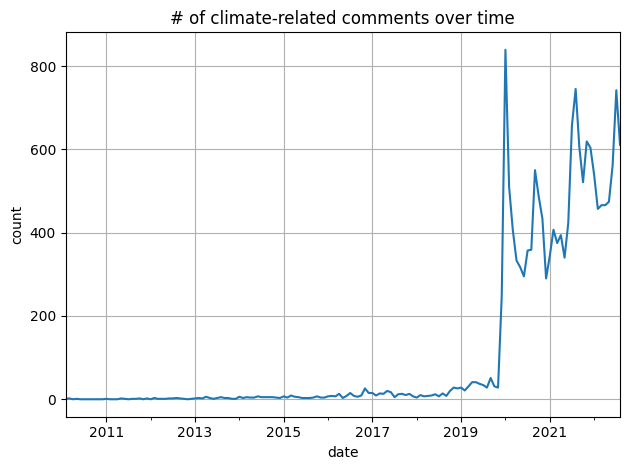

In [ ]:

df['created_datetime'] = pd.to_datetime(df['created_utc'], unit='s')

comments_over_time = df.set_index('created_datetime').resample('ME').size()

comments_over_time.plot(kind='line')
plt.title('# of climate-related comments over time')
# plt.locator_params(axis='x', nbins=20)
plt.xlabel('date')
plt.ylabel('count')
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '# of climate comments by subreddit')

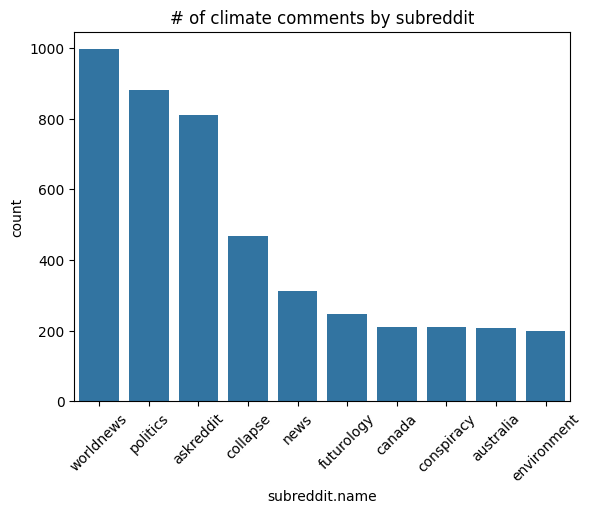

In [ ]:
sns.barplot(df['subreddit.name'].value_counts().head(10))
plt.xticks(rotation=45)
plt.title("# of climate comments by subreddit")

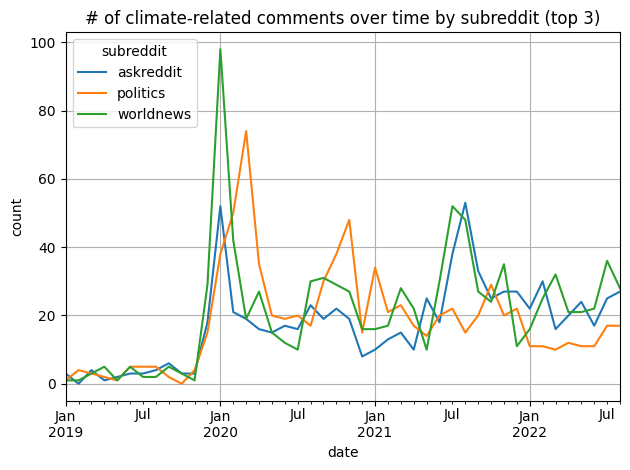

In [ ]:

srs_cts = df['subreddit.name'].value_counts().head(3).index
df_top_srs = df[df['subreddit.name'].isin(srs_cts)]
df_top_srs = df_top_srs[df_top_srs['created_datetime']> '2019']

sr_comments_over_time = df_top_srs.groupby([
    pd.Grouper(key='created_datetime', freq='ME'),
    'subreddit.name'
]).size().unstack(fill_value=0)

sr_comments_over_time.plot(kind='line', ax=plt.gca())
plt.figsize=(10,10)
plt.title('# of climate-related comments over time by subreddit (top 3)')
plt.xlabel('date')
plt.ylabel('count')
plt.legend(title='subreddit', loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


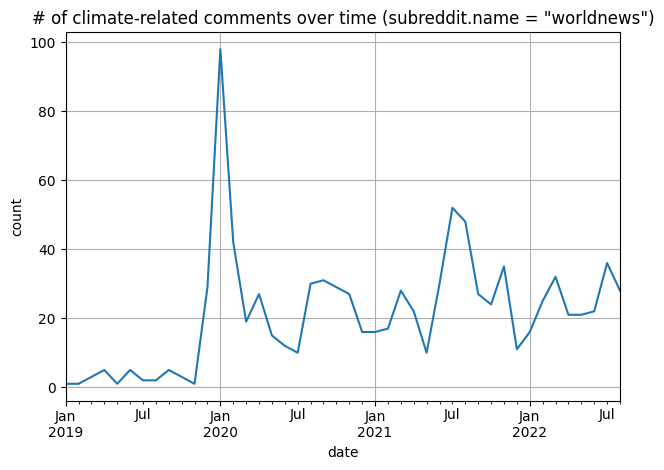

In [ ]:

comments_over_time = df_top_srs[df_top_srs['subreddit.name']== "worldnews"].set_index('created_datetime').resample('ME').size()

comments_over_time.plot(kind='line')
plt.title('# of climate-related comments over time (subreddit.name = "worldnews")')
# plt.locator_params(axis='x', nbins=20)
plt.xlabel('date')
plt.ylabel('count')
plt.grid(True)
plt.tight_layout()
plt.show()

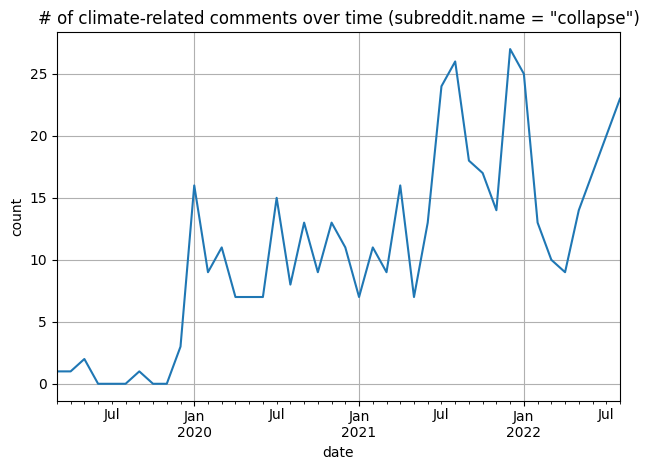

In [ ]:
df_filter = df[df['created_datetime'] > '2019']
comments_over_time = df_filter[df_filter['subreddit.name']== "collapse"].set_index('created_datetime').resample('ME').size()

comments_over_time.plot(kind='line')
plt.title('# of climate-related comments over time (subreddit.name = "collapse")')
# plt.locator_params(axis='x', nbins=20)
plt.xlabel('date')
plt.ylabel('count')
plt.grid(True)
plt.tight_layout()
plt.show()

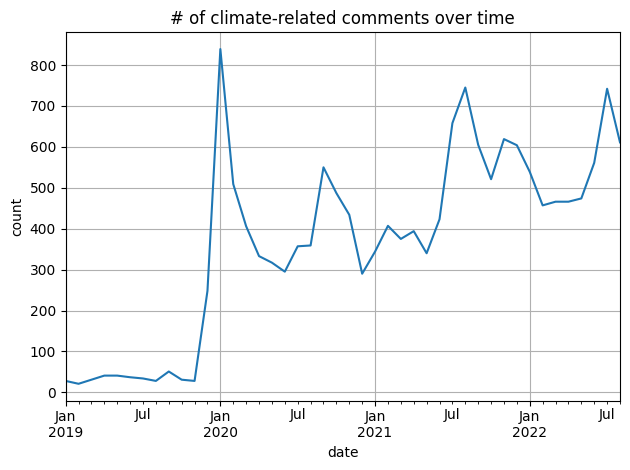

In [ ]:

df['created_datetime'] = pd.to_datetime(df['created_utc'], unit='s')

comments_over_time = df[df['created_datetime']>'2019'].set_index('created_datetime').resample('ME').size()

comments_over_time.plot(kind='line')
plt.title('# of climate-related comments over time')
# plt.locator_params(axis='x', nbins=20)
plt.xlabel('date')
plt.ylabel('count')
plt.grid(True)
plt.tight_layout()
plt.show()

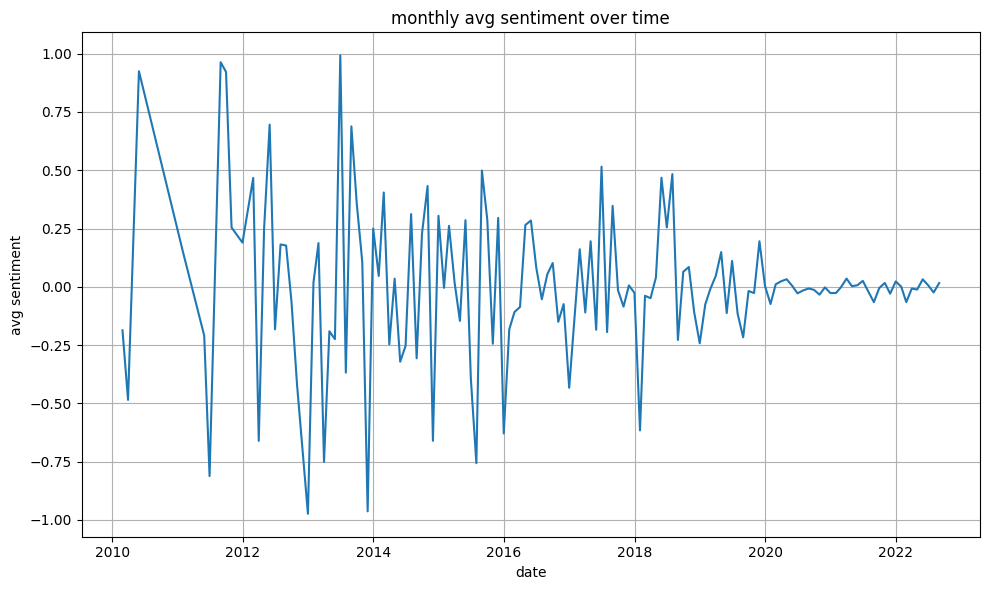

In [ ]:
monthly_sentiment = df.set_index('created_datetime')['sentiment'].resample('ME').mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_sentiment.index, y=monthly_sentiment.values)
plt.title('monthly avg sentiment over time')
plt.xlabel('date')
plt.ylabel('avg sentiment')
plt.grid(True)
plt.tight_layout()
plt.show()

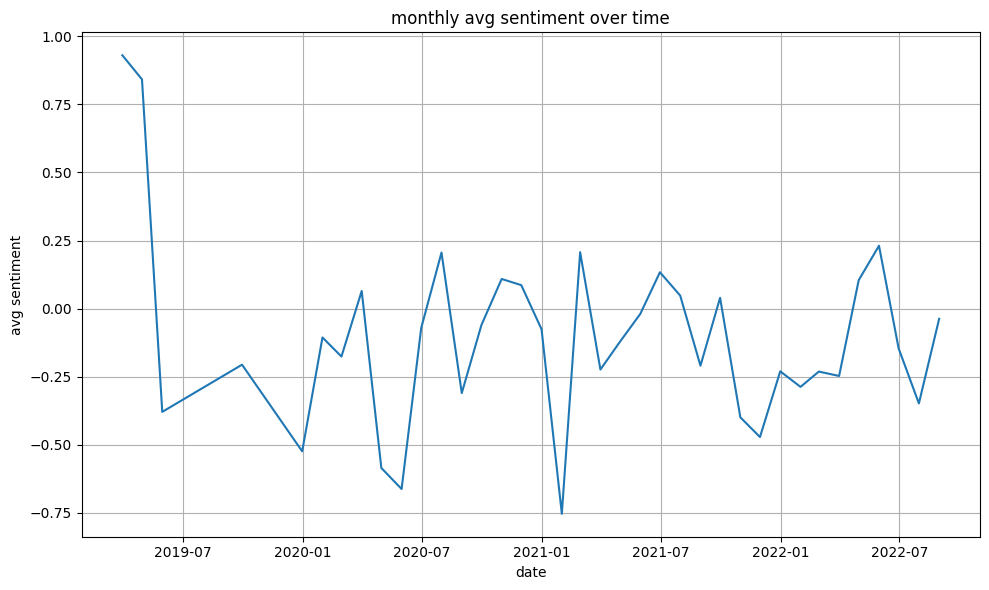

In [ ]:
sentiment_over_time_collapse = df_filter[df_filter['subreddit.name']== "collapse"].set_index('created_datetime')['sentiment'].resample('ME').mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=sentiment_over_time_collapse.index, y=sentiment_over_time_collapse.values)
plt.title('monthly avg sentiment over time')
plt.xlabel('date')
plt.ylabel('avg sentiment')
plt.grid(True)
plt.tight_layout()
plt.show()

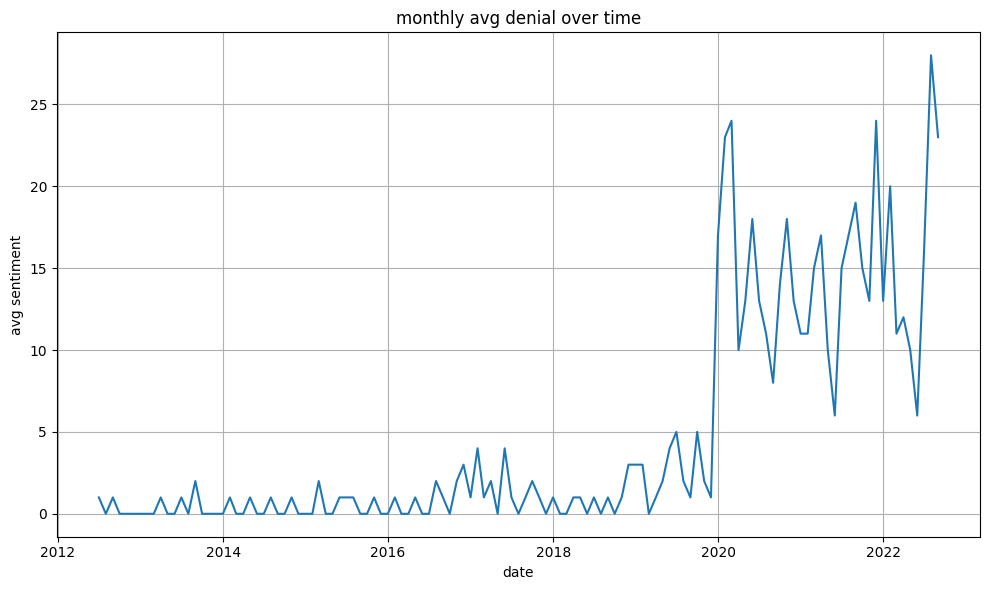

In [ ]:
avg_denial = df[df['label_clean']== "climate denial"].set_index('created_datetime').resample('ME').size()
avg_denial
plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_denial.index, y=avg_denial.values)
plt.title('monthly avg denial over time')
plt.xlabel('date')
plt.ylabel('avg sentiment')
plt.grid(True)
plt.tight_layout()
plt.show()

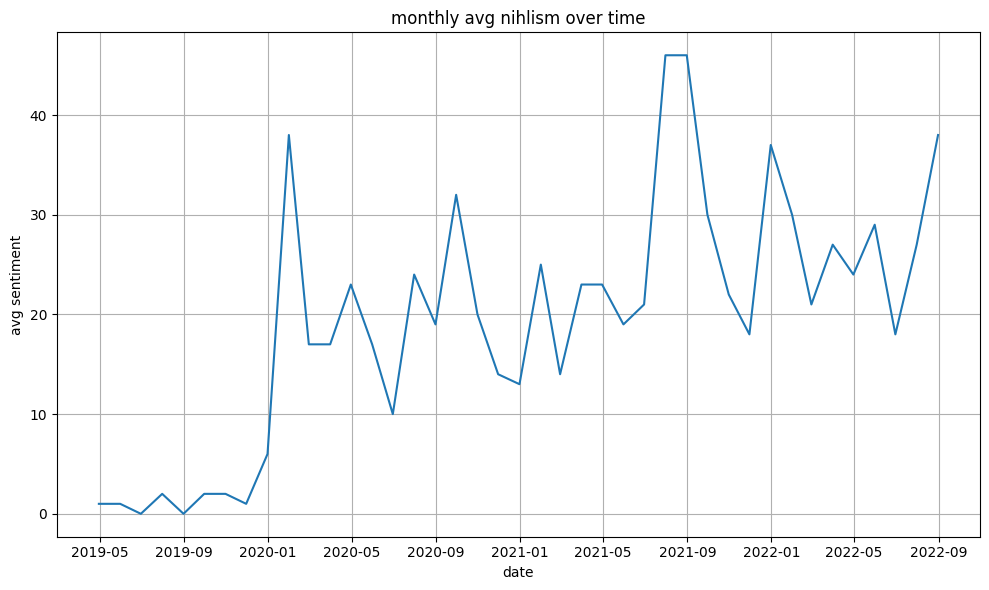

In [ ]:
avg_nihilism = df[(df['label_clean']== "climate nihilism") & (df['created_datetime'] > '2019')].set_index('created_datetime').resample('ME').size()
plt.figure(figsize=(10, 6))
sns.lineplot(x=avg_nihilism.index, y=avg_nihilism.values)
plt.title('monthly avg nihlism over time')
plt.xlabel('date')
plt.ylabel('avg sentiment')
plt.grid(True)
plt.tight_layout()
plt.show()